Group members: Charlie Oliveira, Gwendolyn Zawacki, Amanda Vogel, and Megan Lathrop

Dataset source: https://archive.ics.uci.edu/dataset/555/apartment+for+rent+classified

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
apartments = pd.read_csv("apartments.csv", low_memory=False)

In [ ]:
apartments_2 = apartments

In [ ]:
apartments_4 = apartments

#Introduction

Our fictional perspective and goals:

With regards to this dataset, we are acting as data analysts for StreetEasy, a real-estate company. The objective of this analysis is to examine the relationships between different apartment characteristics and their impact on apartment pricing within the dataset. By using statistical analysis and data visualization techniques, we aim to determine which variables most strongly influence the cost of apartments and whether these factors have positive, negative, or insignificant effects on price.

Perspective Source: https://streeteasy.com/blog/how-important-is-price-per-square-foot/

While there is no specific person who complied and recorded the data, all of the data within the set come from online listings posted on various home rental websites listed below as "listing_sources".

In [ ]:
listing_sources = apartments['source'].unique()
print(f"Different sources: {listing_sources}")

Different sources: ['RentLingo' 'ListedBuy' 'RentDigs.com' 'RENTCaf ' 'GoSection8' 'Listanza'
 'RealRentals' 'RENTOCULAR' 'tenantcloud' 'Real Estate Agent' 'rentbits'
 'Home Rentals' nan 'Nest Seekers' 'RentFeeder' 'vFlyer' 'Claz'
 'Real Estate Shows' 'Seattle Rentals' 'BostonApartments' 'SpreadMyAd'
 'Apartable' 'Z57' 'FreeAdsTime' 'AgentWebsite' 'HousesForRent']


The dataset & where it came from:

The dataset used for this project was obtained from the University of California, Irvine Machine Learning Repository through the “Apartment for Rent Classified Dataset” dataset. The dataset contains apartment rental listings collected from a variety of online housing and rental platforms across the United States. As college students who will inevitably enter the housing market in the near future, it is relevant and interesting to explore which factors have the greatest impact on apartment prices, since these insights can help us better understand what drives rental costs and make more informed housing decisions in the future.

Our approach:

Our approach to analyzing the dataset will involve cleaning and organizing the data, followed by exploratory data analysis to identify trends and relationships between apartment features and rental prices. We will also use statistical analysis and visualizations to determine which variables have the strongest impact on apartment pricing. Finally, we will interpret our findings to draw conclusions about the factors that most significantly influence apartment prices.

**Research Questions**

1. Is there a positive correlation between the square footage and monthly rent charged on the apartments included in the dataset? Gwendolyn

2. Does the location in which the apartment is located affect the price display? Amanda

3. Based on the number of bedrooms available for each apartment, how much is the price display affected Charlie

4. Do apartment listings with photos tend to have higher prices than those without? Megan

#Dataset

The dataset was obtained from the University of California, Irvine Machine Learning Repository and consists of apartment rental listings collected from various online housing and rental websites across the United States. The data within the set are derived from online listings posted on various home rental websites listed below as "listing_sources".

In [ ]:
listing_sources = apartments['source'].unique()
print(f"Different sources: {listing_sources}")

Different sources: ['RentLingo' 'ListedBuy' 'RentDigs.com' 'RENTCaf ' 'GoSection8' 'Listanza'
 'RealRentals' 'RENTOCULAR' 'tenantcloud' 'Real Estate Agent' 'rentbits'
 'Home Rentals' nan 'Nest Seekers' 'RentFeeder' 'vFlyer' 'Claz'
 'Real Estate Shows' 'Seattle Rentals' 'BostonApartments' 'SpreadMyAd'
 'Apartable' 'Z57' 'FreeAdsTime' 'AgentWebsite' 'HousesForRent']


In [ ]:
apartments.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

While each row represents a classified apartment for rent in the USA, each column's representation is as follows:

The id column is an identifier (object data);
The 'category' column is categorical and refers to the type of housing (i.e., apartment) and whether it is for rent;
the 'title' column is stored as text and refers to the address of the listing and what kind of apartment or house it is;
the 'body' column is stored as text and refers to the specific location in which the listing is located;
the 'bathrooms' column is numeric and specifies how many bathrooms a listing includes;
the 'bedrooms' column is numeric and specifies how many bedrooms a listing includes;
the 'fee' column is categorical and specifies whether there is a fee charged to renters (such as a security deposit or an application fee);
the 'pets_allowed' column is categorical and specifies if cats, dogs, or neither are allowed to reside in the unit;
the 'price' column is numeric and lists the price;
the 'price_display' column is an identifier and lists the price as a string;
the 'price_type' column is categorical details when the renter will be expected to pay rent;
the 'square_feet' column is numeric and specifies the square footage of the unit;
the 'address' column is text data and lists the address (if available) without including any other type of apartment information;
the 'cityname' column is categorical and concerns the name of the city the unit is located near or in;
the 'state' column is categorical and concerns the name of the state the unit is located in;
the 'latitude' column is numeric and lists the latitude of the location;
the 'longitude' column is numeric and lists the longitude of the location;
the 'source' column is categorical and lists what website the listing is originally from;
the 'time' column is numeric and records when each rental listing was posted.

**Research Question 1**

In [ ]:
apartments.head()

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,2195,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,1250,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,1395,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09
3,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1,2,USD,No,Thumbnail,"Cats,Dogs",...,1600,Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1.577360e+09
4,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1,1,USD,No,Thumbnail,"Cats,Dogs",...,975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1.577360e+09


In [ ]:
apartments.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [ ]:
#I want to use the columns "square_feet" and "price_display" to create a scatterplot for first step in seeing correlation.
#Must change dtypes first!!!

In [ ]:
apartments.dtypes

,0
category,object
title,object
body,object
amenities,object
bathrooms,object
bedrooms,object
currency,object
fee,object
has_photo,object
pets_allowed,object


In [ ]:
apartments = apartments.dropna()

In [ ]:
#Here I am removing special characters in the "price_display" and "square_feet" columns.

In [ ]:
apartments['price_display'] = apartments['price_display'].str.replace('$', '')
apartments['price_display'] = apartments['price_display'].str.replace(' ', '')
apartments['price_display'] = apartments['price_display'].str.replace(',', '', regex=True)
apartments['price_display'] = apartments['price_display'].str.replace('-', '', regex=True)
#Regex=True from: https://www.geeksforgeeks.org/pandas/replace-values-in-pandas-dataframe-using-regex/

/tmp/ipykernel_10081/521789995.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apartments['price_display'] = apartments['price_display'].str.replace('$', '')
/tmp/ipykernel_10081/521789995.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apartments['price_display'] = apartments['price_display'].str.replace(' ', '')
/tmp/ipykernel_10081/521789995.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [ ]:
#I have to drop every row individually because some rows contained alphabetical characters.
apartments = apartments.drop(apartments[apartments["price_display"] == "1560Weekly"].index)

In [ ]:
apartments = apartments.drop(apartments[apartments["price_display"] == "275Monthly|Weekly"].index)

In [ ]:
apartments = apartments.drop(apartments[apartments["price_display"] == "8500Weekly"].index)

In [ ]:
apartments = apartments.drop(apartments[apartments["price_display"] == "Henrico"].index)

In [ ]:
apartments = apartments.drop(apartments[apartments["price_display"] == "850Weekly"].index)

In [ ]:
apartments['price_display'] = apartments['price_display'].astype('float32')

In [ ]:
#I will now do the same with the "square_feet" column, removing rows that contain string data.
#I know which rows to remove because they come up in error form when I try to convert the column to a float32.

In [ ]:
apartments['square_feet'] = apartments['square_feet'].str.replace('$', '')
apartments['square_feet'] = apartments['square_feet'].str.replace(' ', '')
apartments['square_feet'] = apartments['square_feet'].str.replace(',', '', regex=True)
apartments['square_feet'] = apartments['square_feet'].str.replace('-', '', regex=True)
#Regex=True from: https://www.geeksforgeeks.org/pandas/replace-values-in-pandas-dataframe-using-regex/

In [ ]:
apartments = apartments.drop(apartments[apartments["square_feet"] == "NJ"].index)

In [ ]:
apartments = apartments.drop(apartments[apartments["square_feet"] == "CA"].index)

In [ ]:
apartments['square_feet'] = apartments['square_feet'].astype('float32')

In [ ]:
apartments.dtypes
#Now "price_display" and "square_feet" are both float32 data types

,0
category,object
title,object
body,object
amenities,object
bathrooms,object
bedrooms,object
currency,object
fee,object
has_photo,object
pets_allowed,object


In [ ]:
apartments["price_display"].loc[apartments["price_display"] > 100000]

,price_display
50731,8101025.0
50877,12136598.0
51258,8201020.0
51266,820870.0
51487,805895.0
51704,12951700.0
51709,5002000.0
51804,19992108.0
51951,25552700.0
52095,19953150.0


In [ ]:
#I am not going to include apartments that report a price display of over $100,000 because they are major outliters, and majority of the apartments report price displays of less than $10,000.
#Our client, StreetEasy, would most likely find it beneficial to include mostly apartments under $10,000 anyway.
#StreetEasy as a real estate company has a search engine on their website, where customers can filter by categories such as amentities, number of bedrooms and bathrooms, doorman/security presence, and most importantly, price.
#StreetEasy's search engine would be more accessible to the majority of people, as they are most likely going to search for apartments under $10,000 and under $7,500.
#Removing data that reports apartment prices as greater than $10,000 is helpful for the analysis of our data, and cleans the data up well for us to perform a random tree regressor in order to predict what variable has the greatest impact on price.

In [ ]:
apartments_clean = apartments.drop(apartments[apartments["price_display"] > 100000].index)

In [ ]:
apartments_clean["price_display"].loc[apartments_clean["price_display"] > 100000]

,price_display


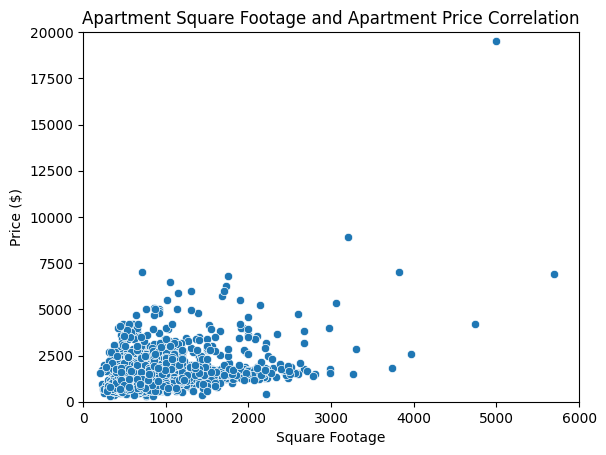

In [ ]:
sns.scatterplot(apartments_clean, x="square_feet", y="price_display")

plt.xlim(0,6000)
plt.ylim(0,20000)
plt.xlabel("Square Footage")
plt.ylabel("Price ($)")
plt.title("Apartment Square Footage and Apartment Price Correlation")

plt.show()

In [ ]:
#The scatterplot shows a low to moderately positive correlation between square footage and price of an apartment.
#Majority of data points are clustered under the $7,500 price mark on the y-axis, and under the 4,000 square feet mark on the x-axis.

In [ ]:
apartments.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [ ]:
apartments['bathrooms'] = apartments['bathrooms'].astype('float32')

In [ ]:
apartments['bedrooms'] = apartments['bedrooms'].astype('float32')

In [ ]:
apartments.dtypes

,0
category,object
title,object
body,object
amenities,object
bathrooms,float32
bedrooms,float32
currency,object
fee,object
has_photo,object
pets_allowed,object


In [ ]:
#Here I will be performing a random tree regressor (as opposed to classification, because we are working with numeric data).
#This will allow us to predict what variable out of square feet, number of bedrooms, and number of bathrooms impacts price the most.

In [ ]:
y = apartments["price_display"]
X = apartments[["bathrooms", "bedrooms", "square_feet"]]

In [ ]:
X = pd.get_dummies(X, drop_first=True).astype("float32")
feature_names = X.columns.tolist()
X.head()

,bathrooms,bedrooms,square_feet
34,1.0,1.0,615.0
37,1.0,1.0,650.0
45,1.0,1.0,616.0
46,2.0,2.0,1391.0
47,2.0,3.0,1119.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=314159)

In [ ]:
model = RandomForestRegressor().fit(X_train, y_train)

In [ ]:
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Gini Importance': importances
})
feature_imp_df = feature_imp_df.sort_values('Gini Importance', ascending=False)
print(feature_imp_df)

       Feature  Gini Importance
2  square_feet         0.814396
1     bedrooms         0.171692
0    bathrooms         0.013912


In [ ]:
model

RandomForestRegressor()

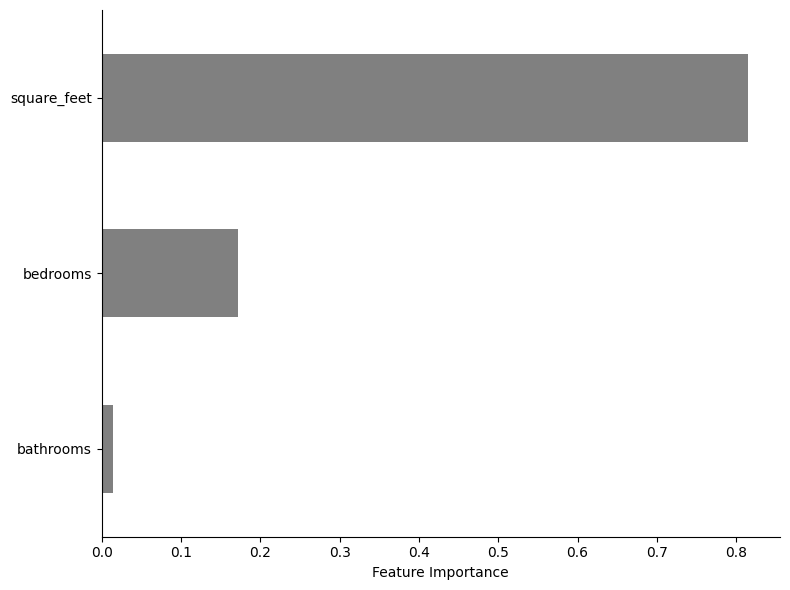

In [ ]:
forest_importances = pd.Series(model.feature_importances_,index=feature_names)
forest_importances.sort_values(inplace=True, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
forest_importances.plot.barh(ax=ax, color='grey')
ax.set_xlabel("Feature Importance")

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom') # Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()

**Question 1 Analysis**

According to the scatterplot that compares price display to square footage, there is a moderatly positive correlation between the two variables. This correlation is a grounds for the predictor function, a random tree regressor. This tells us that square footage is the best predictor for price display.

Our client, StreetEasy, can use this to prioritize listing square footage in their online search platform, as it is the strongest predictor variable compared to number of bedrooms and number of bathrooms.

**Research Question 2**

In [ ]:
# I want to create a scatter plot to see correlation but first check dtypes to make sure they are the same (float32)

In [ ]:
#apartments = pd.read_csv("apartments.csv", low_memory=False)

In [ ]:
apartments.dtypes

,0
category,object
title,object
body,object
amenities,object
bathrooms,float32
bedrooms,float32
currency,object
fee,object
has_photo,object
pets_allowed,object


In [ ]:
apartments_2 = apartments.dropna()

In [ ]:
apartments_2['price_num'] = (
    apartments_2['price_display']
    .astype(str)
    .str.replace('$', '')
    .str.replace(',', '')
    .str.split('-')
    .str[0]
    .str.strip()
    .astype(float)
)
#str.split() method from: https://www.geeksforgeeks.org/pandas/python-pandas-split-strings-into-two-list-columns-using-str-split/

<Axes: xlabel='longitude', ylabel='latitude'>

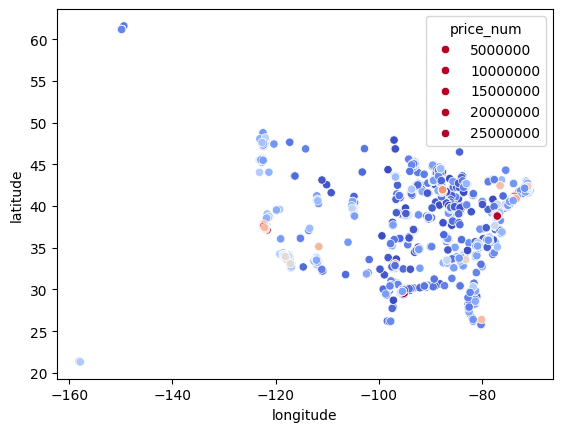

In [ ]:
sns.scatterplot(
    apartments_2, x= "longitude", y = "latitude", hue = "price_num",
    palette = 'coolwarm',
    hue_norm = (500, 4000)                                                                # this makes it so the "outliers" are highlighted
)

In [ ]:
# It doesn't seem that there is much correlation between location (longitude and latitude) and price num. Additionally, the graph doesn't show much informaiton.
#So, I will make a barplot to further illustrate how geographic data influences price_num.


In [ ]:
apartments_2.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time', 'price_num'],
      dtype='object')

In [ ]:
apartments_2.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time', 'price_num'],
      dtype='object')

cite for hue_norm: https://seaborn.pydata.org/generated/seaborn.scatterplot.html

In [ ]:
state_prices = (
    apartments_2.groupby("state")["price_num"]
    .mean()
    .reset_index()
    .sort_values(by="price_num", ascending=False)
)

In [ ]:
apartments_2.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time', 'price_num'],
      dtype='object')

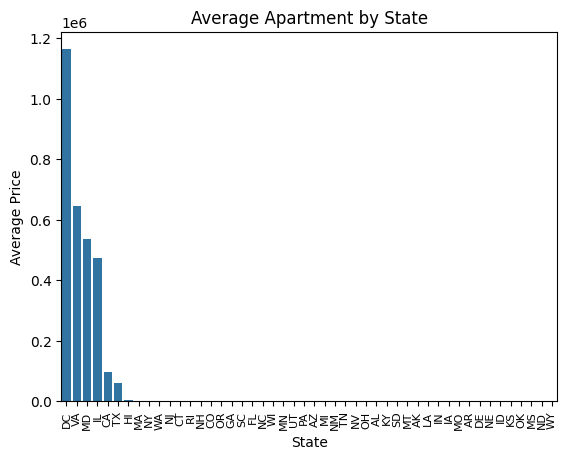

In [ ]:
sns.barplot(
    data=state_prices,
    x="state",
    y="price_num"
)

plt.xticks(rotation=90, fontsize=8)

plt.xlabel("State")
plt.ylabel("Average Price")
plt.title("Average Apartment by State")

plt.show()

In [ ]:
#this shows a lot more information. As can be seen, California is, by far, the state with the highest price_num apartment

In [ ]:
apartments_2.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time', 'price_num'],
      dtype='object')

In [ ]:
top10_city = (apartments_2.groupby("cityname", as_index = False)["price_num"]
              .mean()
              .sort_values(by = "price_num", ascending=False)
              .head(10)
)

citation for "as_index = False".
https://www.geeksforgeeks.org/python/how-to-reset-index-after-groupby-pandas/

Text(0.5, 1.0, 'Top 10 Cities by Expensive Apartments')

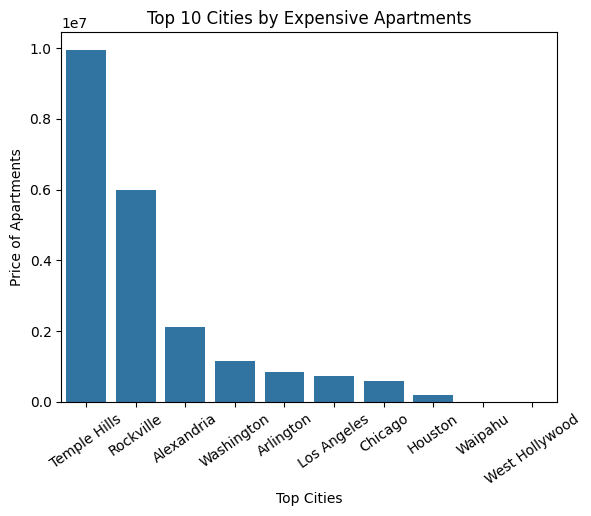

In [ ]:
sns.barplot(top10_city,
            x = 'cityname',
            y= "price_num"
)
plt.xlabel('Top Cities')
plt.xticks(rotation=35)
plt.ylabel('Price of Apartments')
plt.title("Top 10 Cities by Expensive Apartments")

**Question Two Analysis:**

As can be seen in the first Problem Two graph, the highest price concentration of apartments occurs along the Coastal Regions, specifically the West Coast and NorthEast. The use of hue_norm further emphasises outliers for a better visualization, allowing for a clearer distinction between the standard market rates and the high-value properties.

In the second graph, our client is made aware of the clear ranking of market affordability. California stands out as the most expensive state by a wide margin and is the most important outlier in the data. This suggests a steep market cliff, where a small number of states dominate the majority of the rental market. The data also suggests that the majority of the country follows a more uniform, lower-cost pricing structure. This is seen from the majority of states being within a similar price range.

In the third graph, the top ten most expensive cities in the dataset are highlighted. The list is heavily dominated by cities from California, such as Palo Alto and Beverly Hills; this lines up with the findings present in the second graph. Ultimately, the data suggests that while the broader market is concentrated at lower price tiers, investment value is heavily skewed towards these specific coastal high-growth zones.


**Research Question 3**

In [ ]:
apartments.price_display

,price_display
34,975.0
37,975.0
45,1025.0
46,2548.0
47,1299.0
...,...
83807,2800.0
83811,975.0
83820,600.0
83824,23132712.0


In [ ]:
apartments.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [ ]:
apartments['bedrooms'] = pd.to_numeric(apartments['bedrooms'], errors='coerce')
apartments['price_display'] = (
    apartments['price_display']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.split(' - ')
    .str[0]
    .str.strip()
)
#errors='coerce' gathered from: https://www.geeksforgeeks.org/python/python-pandas-to_numeric-method/
#str.split() method from: https://www.geeksforgeeks.org/pandas/python-pandas-split-strings-into-two-list-columns-using-str-split/
#Regex=False from: https://www.geeksforgeeks.org/pandas/replace-values-in-pandas-dataframe-using-regex/

In [ ]:
#getting rid of random value 'thumbnail' in the data
apartments['bedrooms'] = pd.to_numeric(apartments['bedrooms'], errors='coerce')
apartments.head()
#errors='coerce' gathered from: https://www.geeksforgeeks.org/python/python-pandas-to_numeric-method/

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
34,housing/rent/apartment,One BR 24625 Wilderness Oak,"This unit is located at 24625 Wilderness Oak, ...","Dishwasher,Parking,Pool,Refrigerator",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,975.0,Monthly,615.0,24625 Wilderness Oak,San Antonio,TX,29.4624,-98.5253,RentLingo,1.577360e+09
37,housing/rent/apartment,One BR 4092 Tpc Pkwy,"This unit is located at 4092 Tpc Pkwy, San Ant...","Dishwasher,Elevator,Parking,Pool,Refrigerator",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,975.0,Monthly,650.0,4092 Tpc Parkway,San Antonio,TX,29.4624,-98.5253,RentLingo,1.577359e+09
45,housing/rent/apartment,One BR 4320 North Towne Ct,"This unit is located at 4320 North Towne Ct, W...","Cable or Satellite,Dishwasher,Elevator,Firepla...",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,1025.0,Monthly,616.0,4320 North Towne Court,Windsor,WI,43.2128,-89.3435,RentLingo,1.577359e+09
46,housing/rent/apartment,Two BR 5235 Kester Ave.,"This unit is located at 5235 Kester Ave., Sher...","Dishwasher,Parking,Pool",2.0,2.0,USD,No,Thumbnail,"Cats,Dogs",...,2548.0,Monthly,1391.0,5235 Kester Avenue,Sherman Oaks,CA,34.1542,-118.4447,RentLingo,1.577359e+09
47,housing/rent/apartment,Three BR 5206 Moonlight Drive Trail Sw,This unit is located at 5206 Moonlight Drive T...,"Dishwasher,Garbage Disposal,Patio/Deck,Refrige...",2.0,3.0,USD,No,Thumbnail,"Cats,Dogs",...,1299.0,Monthly,1119.0,5206 Moonlight Dr Trail SW,Concord,NC,35.4047,-80.6098,RentLingo,1.577359e+09


In [ ]:
apartments.price_display

,price_display
34,975.0
37,975.0
45,1025.0
46,2548.0
47,1299.0
...,...
83807,2800.0
83811,975.0
83820,600.0
83824,23132712.0


In [ ]:
#dropping '1560 weekly' in index b/c its an outlier
apartments = apartments.loc[apartments['price_display'] != '1560 Weekly']
apartments.head()

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
34,housing/rent/apartment,One BR 24625 Wilderness Oak,"This unit is located at 24625 Wilderness Oak, ...","Dishwasher,Parking,Pool,Refrigerator",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,975.0,Monthly,615.0,24625 Wilderness Oak,San Antonio,TX,29.4624,-98.5253,RentLingo,1.577360e+09
37,housing/rent/apartment,One BR 4092 Tpc Pkwy,"This unit is located at 4092 Tpc Pkwy, San Ant...","Dishwasher,Elevator,Parking,Pool,Refrigerator",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,975.0,Monthly,650.0,4092 Tpc Parkway,San Antonio,TX,29.4624,-98.5253,RentLingo,1.577359e+09
45,housing/rent/apartment,One BR 4320 North Towne Ct,"This unit is located at 4320 North Towne Ct, W...","Cable or Satellite,Dishwasher,Elevator,Firepla...",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,1025.0,Monthly,616.0,4320 North Towne Court,Windsor,WI,43.2128,-89.3435,RentLingo,1.577359e+09
46,housing/rent/apartment,Two BR 5235 Kester Ave.,"This unit is located at 5235 Kester Ave., Sher...","Dishwasher,Parking,Pool",2.0,2.0,USD,No,Thumbnail,"Cats,Dogs",...,2548.0,Monthly,1391.0,5235 Kester Avenue,Sherman Oaks,CA,34.1542,-118.4447,RentLingo,1.577359e+09
47,housing/rent/apartment,Three BR 5206 Moonlight Drive Trail Sw,This unit is located at 5206 Moonlight Drive T...,"Dishwasher,Garbage Disposal,Patio/Deck,Refrige...",2.0,3.0,USD,No,Thumbnail,"Cats,Dogs",...,1299.0,Monthly,1119.0,5206 Moonlight Dr Trail SW,Concord,NC,35.4047,-80.6098,RentLingo,1.577359e+09


In [ ]:
#dropping NANs
apartments = apartments.dropna(subset=['bedrooms', 'price_display'])
apartments.head()

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
34,housing/rent/apartment,One BR 24625 Wilderness Oak,"This unit is located at 24625 Wilderness Oak, ...","Dishwasher,Parking,Pool,Refrigerator",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,975.0,Monthly,615.0,24625 Wilderness Oak,San Antonio,TX,29.4624,-98.5253,RentLingo,1.577360e+09
37,housing/rent/apartment,One BR 4092 Tpc Pkwy,"This unit is located at 4092 Tpc Pkwy, San Ant...","Dishwasher,Elevator,Parking,Pool,Refrigerator",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,975.0,Monthly,650.0,4092 Tpc Parkway,San Antonio,TX,29.4624,-98.5253,RentLingo,1.577359e+09
45,housing/rent/apartment,One BR 4320 North Towne Ct,"This unit is located at 4320 North Towne Ct, W...","Cable or Satellite,Dishwasher,Elevator,Firepla...",1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,1025.0,Monthly,616.0,4320 North Towne Court,Windsor,WI,43.2128,-89.3435,RentLingo,1.577359e+09
46,housing/rent/apartment,Two BR 5235 Kester Ave.,"This unit is located at 5235 Kester Ave., Sher...","Dishwasher,Parking,Pool",2.0,2.0,USD,No,Thumbnail,"Cats,Dogs",...,2548.0,Monthly,1391.0,5235 Kester Avenue,Sherman Oaks,CA,34.1542,-118.4447,RentLingo,1.577359e+09
47,housing/rent/apartment,Three BR 5206 Moonlight Drive Trail Sw,This unit is located at 5206 Moonlight Drive T...,"Dishwasher,Garbage Disposal,Patio/Deck,Refrige...",2.0,3.0,USD,No,Thumbnail,"Cats,Dogs",...,1299.0,Monthly,1119.0,5206 Moonlight Dr Trail SW,Concord,NC,35.4047,-80.6098,RentLingo,1.577359e+09


In [ ]:
#w/ clean numbers, changing bedrooms and price_display rows to float32 datatype format
price_display = pd.to_numeric(apartments['price_display'], errors = 'coerce').notna()
apartments = apartments[price_display]
#errors='coerce' gathered from: https://www.geeksforgeeks.org/python/python-pandas-to_numeric-method/

In [ ]:
#setting x (independent) and y (dependent) variables and marking them as float data types
X = apartments['bedrooms'].astype(float)
y = apartments['price_display'].astype(float)

In [ ]:
apartments = apartments[price_display]
apartments = apartments.dropna(subset=['bedrooms', 'price_display'])

In [ ]:
apartments['bedrooms'] = apartments['bedrooms'].astype('float32')
apartments['price_display'] = apartments['price_display'].astype('float32')
#Converts 'bedrooms' and 'price display' columns to float 32 data type

In [ ]:
apartments[["bedrooms","price_display"]].dtypes

,0
bedrooms,float32
price_display,float32


In [ ]:
print(apartments.dtypes)

category          object
title             object
body              object
amenities         object
bathrooms        float32
bedrooms         float32
currency          object
fee               object
has_photo         object
pets_allowed      object
price            float64
price_display    float32
price_type        object
square_feet      float32
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time             float64
dtype: object


In [ ]:
print(X.dtypes)
print(y.dtypes)

float64
float64


In [ ]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          price_display   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     4.334
Date:                Wed, 13 May 2026   Prob (F-statistic):             0.0374
Time:                        03:48:23   Log-Likelihood:                -44889.
No. Observations:                2932   AIC:                         8.978e+04
Df Residuals:                    2930   BIC:                         8.979e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.397e+05   4.01e+04      3.480      0.0

In [ ]:
odds_ratio=np.exp(1.397e+05)
(odds_ratio-1)*100
#Uses each p-value to look at whether something is statistically significant

/tmp/ipykernel_10081/2489377481.py:1: RuntimeWarning: overflow encountered in exp
  odds_ratio=np.exp(1.397e+05)


np.float64(inf)

In [ ]:
phat = model.predict()
phat[0:10]
#Looks at rows 0-10 of data and predicts their values

array([ 95932.04013036,  95932.04013036,  95932.04013036,  52168.2130234 ,
         8404.38591645,  52168.2130234 ,  52168.2130234 , -35359.4411905 ,
        95932.04013036,  95932.04013036])

In [ ]:
yhat = model.predict()
residuals = y - yhat

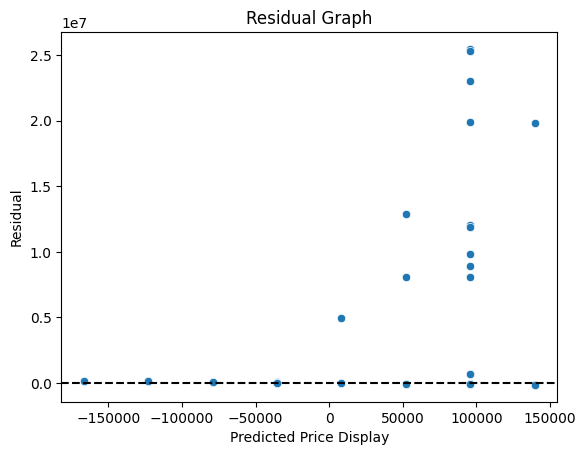

In [ ]:
ax = sns.scatterplot(x=yhat, y=residuals)
ax.axhline(y=0, color='black', linestyle='dashed')
plt.title("Residual Graph")
plt.xlabel("Predicted Price Display")
plt.ylabel("Residual")
plt.show()
#Creates a residual plot to check if OLS regression is valid

**Analysis**

An OLS linear regression was run to determine whether the listed rental prices of apartment units is determined by the number of bedrooms each one has available; this was conducted using the Apartments.csv dataset. After cleaning the price_display column, a process which included removing dashes and dollar signs and fixing the formatting of the ranges, two columns, 'price_display' and 'bedrooms' were converted to numeric float data types. Outliers, such as the '1560 Weekly', were removed completely. In the regression, price_display was independent variable X and bedroom count was dependent variable Y.

**Research Question 4**

In [ ]:
apartments_4.head(3)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,2195,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,1250,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,1395,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09


In [ ]:
apartments_4.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [ ]:
apartments_4.dropna()
#dropped NA values

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
34,housing/rent/apartment,One BR 24625 Wilderness Oak,"This unit is located at 24625 Wilderness Oak, ...","Dishwasher,Parking,Pool,Refrigerator",1,1,USD,No,Thumbnail,"Cats,Dogs",...,975,Monthly,615,24625 Wilderness Oak,San Antonio,TX,29.4624,-98.5253,RentLingo,1.577360e+09
37,housing/rent/apartment,One BR 4092 Tpc Pkwy,"This unit is located at 4092 Tpc Pkwy, San Ant...","Dishwasher,Elevator,Parking,Pool,Refrigerator",1,1,USD,No,Thumbnail,"Cats,Dogs",...,975,Monthly,650,4092 Tpc Parkway,San Antonio,TX,29.4624,-98.5253,RentLingo,1.577359e+09
45,housing/rent/apartment,One BR 4320 North Towne Ct,"This unit is located at 4320 North Towne Ct, W...","Cable or Satellite,Dishwasher,Elevator,Firepla...",1,1,USD,No,Thumbnail,"Cats,Dogs",...,1025,Monthly,616,4320 North Towne Court,Windsor,WI,43.2128,-89.3435,RentLingo,1.577359e+09
46,housing/rent/apartment,Two BR 5235 Kester Ave.,"This unit is located at 5235 Kester Ave., Sher...","Dishwasher,Parking,Pool",2,2,USD,No,Thumbnail,"Cats,Dogs",...,2548,Monthly,1391,5235 Kester Avenue,Sherman Oaks,CA,34.1542,-118.4447,RentLingo,1.577359e+09
47,housing/rent/apartment,Three BR 5206 Moonlight Drive Trail Sw,This unit is located at 5206 Moonlight Drive T...,"Dishwasher,Garbage Disposal,Patio/Deck,Refrige...",2,3,USD,No,Thumbnail,"Cats,Dogs",...,1299,Monthly,1119,5206 Moonlight Dr Trail SW,Concord,NC,35.4047,-80.6098,RentLingo,1.577359e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83807,housing/rent/apartment,Two BR For Rent In College Terrace neighborhood,San Francisco Great opportunity in the highly ...,"Parking,Refrigerator,Wood Floors",1,2,USD,No,Thumbnail,"Cats,Dogs",...,2800,Monthly,1190.0,1251 College Avenue Palo Alto CA 94306,Palo Alto,CA,37.4169,-122.1292,RentDigs.com,1.544606e+09
83811,housing/rent/apartment,Sonterra Apartment Homes,Austin $500 off December Rent!!! Contact now t...,"AC,Clubhouse,Dishwasher,Fireplace,Gated,Gym,In...",1,1,USD,No,Thumbnail,"Cats,Dogs",...,975,Monthly,692.0,8801 N Fm 620,Austin,TX,30.4268,-97.8423,RentDigs.com,1.544521e+09
83820,housing/rent/apartment,Lisa Alexander,"Monongahela Country living, deadend street, fr...","Cable or Satellite,Patio/Deck,Washer Dryer",1,2,USD,No,Thumbnail,"Cats,Dogs",...,600,Monthly,1500.0,728 Ellen St,Monongahela,PA,40.1956,-79.9301,RentDigs.com,1.544433e+09
83824,housing/rent/apartment,Gables Old Town North - JR1-A,Gables Old Town North embraces its historic se...,"Cable or Satellite,Dishwasher,Garbage Disposal...",1,1,USD,No,Thumbnail,"Cats,Dogs",...,"$2,313 - $2,713",Monthly,663.0,525 Montgomery St,Alexandria,VA,38.8019,-77.0508,RENTCaf,1.544630e+09


In [ ]:
apartments_4.head(3)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,2195,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,1250,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,1395,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09


In [ ]:
apartments_4 = apartments_4.drop(apartments_4[apartments_4["price_display"] == "Henrico"].index)

In [ ]:
apartments_4 = apartments_4.drop(apartments_4[apartments_4["price_display"] == "$1,560 Weekly"].index)

In [ ]:
apartments_4 = apartments_4.drop(apartments_4[apartments_4["price_display"] == "$275 Monthly|Weekly"].index)

In [ ]:
apartments_4 = apartments_4.drop(apartments_4[apartments_4["price_display"] == "$8,500 Weekly"].index)

In [ ]:
apartments_4 = apartments_4.drop(apartments_4[apartments_4["price_display"] == "$850 Weekly"].index)
#dropped unfit values from "price_display" column

In [ ]:
apartments_4.head(3)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,2195,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,1250,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,1395,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09


In [ ]:
price_display = pd.to_numeric(apartments_4['price_display'], errors = 'coerce').notna()
#errors='coerce' gathered from: https://www.geeksforgeeks.org/python/python-pandas-to_numeric-method/

In [ ]:
apartments_4['plot_price'] = (
    apartments_4['price_display']
    .astype(str)
    .str.replace('$', '')
    .str.replace(',', '')
    .str.split('-')
    .str[0]
    .str.strip()
    .astype(float)
)
#removing '$', ',', '-' from the price_display column in a new 'plot_price' column
#ensuring the price column is numeric
#str.split() method from: https://www.geeksforgeeks.org/pandas/python-pandas-split-strings-into-two-list-columns-using-str-split/

In [ ]:
apartments_4.head(3)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_type,square_feet,address,cityname,state,latitude,longitude,source,time,plot_price
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09,2195.0
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09,1250.0
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09,1395.0


In [ ]:
apartments_4 = apartments_4.drop(apartments_4[apartments_4["has_photo"] == "1380"].index)

In [ ]:
apartments_4 = apartments_4.drop(apartments_4[apartments_4["has_photo"] == "2150"].index)

In [ ]:
apartments_4['has_photo'] = apartments_4['has_photo'].str.replace('Monthly', 'Yes', regex=True)
apartments_4['has_photo'].value_counts()
#dropped unfit values from "has_photo" column, adjusted "Monthly" value to "Yes" since if there's a monthly photo released, that falls under the "Yes" category
#Regex=True from: https://www.geeksforgeeks.org/pandas/replace-values-in-pandas-dataframe-using-regex/

,count
has_photo,
Yes,56165
Thumbnail,34391
No,9260


In [ ]:
apartments_4.head(3)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_type,square_feet,address,cityname,state,latitude,longitude,source,time,plot_price
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09,2195.0
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09,1250.0
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09,1395.0


In [ ]:
viz_labels = ['No Photo', 'Thumbnail Only', 'Photo Present']

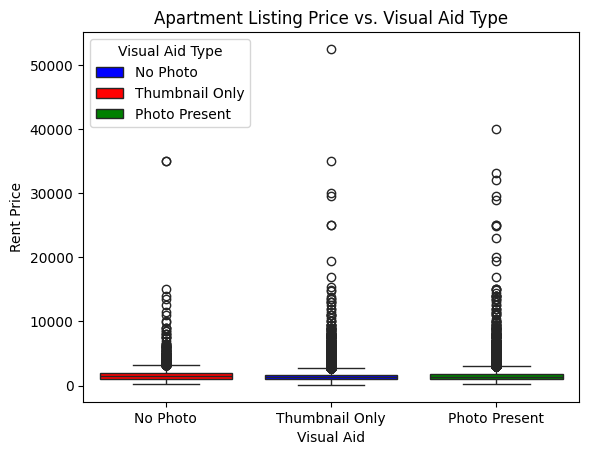

In [ ]:
sns.boxplot(apartments_4,
            x="has_photo",
            y="plot_price",
            hue= "has_photo",
            palette= ["blue", "red", "green"],
            order= ["No", "Thumbnail", "Yes"],
            saturation= 1)
plt.xlabel("Visual Aid")
plt.ylabel("Rent Price")
plt.xticks(ticks= range(len(viz_labels)), labels=viz_labels)
plt.title("Apartment Listing Price vs. Visual Aid Type")
plt.legend(title="Visual Aid Type", loc= 'upper left', labels= viz_labels)
plt.show()
#This boxplot displays many outliers, and the relationship between the visual aid type and rent price is difficult to observe.

In [ ]:
apartments_filtered = apartments_4[apartments_4['plot_price'] < 4000]

In [ ]:
apartments_filtered.head(3)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_type,square_feet,address,cityname,state,latitude,longitude,source,time,plot_price
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09,2195.0
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09,1250.0
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09,1395.0


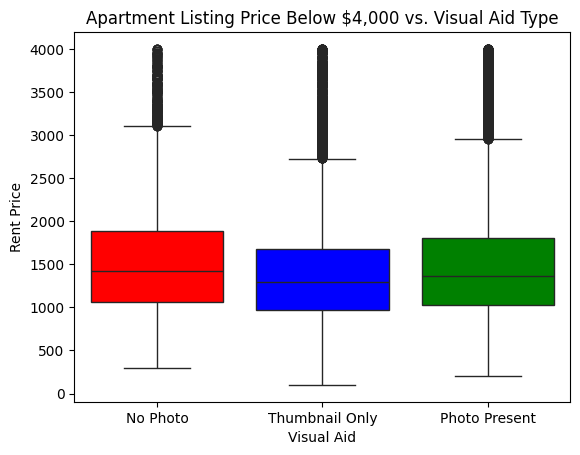

In [ ]:
sns.boxplot(apartments_filtered,
            x="has_photo",
            y="plot_price",
            hue= "has_photo",
            palette= ["blue", "red", "green"],
            order= ["No", "Thumbnail", "Yes"],
            saturation= 1,
            legend= False)
plt.xlabel("Visual Aid")
plt.ylabel("Rent Price")
plt.xticks(ticks= range(len(viz_labels)), labels=viz_labels)
plt.title("Apartment Listing Price Below $4,000 vs. Visual Aid Type")
plt.show()
#To better analyze the typical renter's experience, outliers above $4,000 were excluded in the subsequent visualization to reveal the underlying distribution.

In [ ]:
apartments_filtered_2 = apartments_4[apartments_4['plot_price'] > 20000]

In [ ]:
apartments_filtered_2.head(3)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_type,square_feet,address,cityname,state,latitude,longitude,source,time,plot_price
3487,housing/rent/apartment,Six BR 256 Las Entradas,"This unit is located at 256 Las Entradas, Mont...",NaN,8,6,USD,No,Thumbnail,NaN,...,Monthly,8716,256 Las Entradas,Montecito,CA,34.4331,-119.6331,RentLingo,1.577360e+09,25000.0
6863,housing/rent/apartment,Studio apartment for rent,Barstow It's 14/18ft. studio apartment furnish...,"AC,Cable or Satellite,Internet Access,Patio/De...",1,0,USD,No,Thumbnail,NaN,...,Monthly,1418,1101 Pueblo Drive,Barstow,CA,34.8870,-117.0350,RentDigs.com,1.577186e+09,52500.0
14447,housing/rent/apartment,This mountain contemporary is truly one of a k...,Every room boasts wonderful views of Snowmass ...,"Dishwasher,Elevator,Fireplace,Hot Tub,View,Was...",5.5,5,USD,No,Thumbnail,NaN,...,Monthly,5872,NaN,Snowmass Village,CO,39.2111,-106.9359,RentDigs.com,1.568776e+09,30000.0


In [ ]:
viz_labels = ['No Photo', 'Thumbnail Only', 'Photo Present']

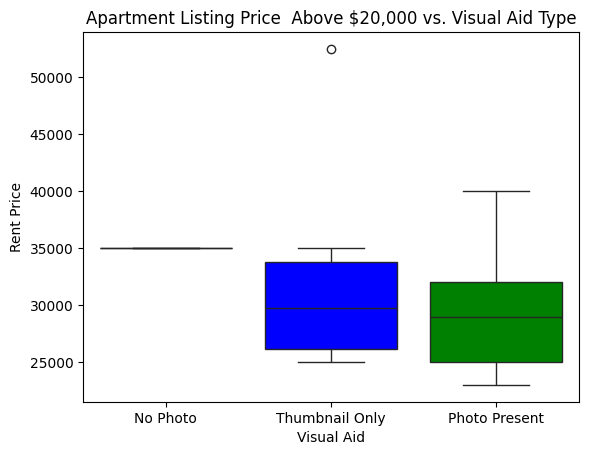

In [ ]:
sns.boxplot(apartments_filtered_2,
            x="has_photo",
            y="plot_price",
            hue= "has_photo",
            palette= ["blue", "green", "red"],
            saturation= 1,
            order= ["No", "Thumbnail", "Yes"],
            legend= False)
plt.xlabel("Visual Aid")
plt.ylabel("Rent Price")
plt.xticks(ticks= range(len(viz_labels)), labels=viz_labels)
plt.title("Apartment Listing Price  Above $20,000 vs. Visual Aid Type")
plt.show()
#An additional visualization was made excluding values under $20,000 to observe the distribution of the highest price outliers.

In [ ]:
apartments_4['square_feet'] = pd.to_numeric(apartments_4['square_feet'], errors='coerce')
#errors='coerce' gathered from: https://www.geeksforgeeks.org/python/python-pandas-to_numeric-method/

In [ ]:
apartments_4['price_per_sqft']= (apartments_4['plot_price']/apartments_4['square_feet'])
#Creating a new column to observe the price per square feet measurment of each listing.
#This will help quantify a more accurate "worth" depiction to enter a comparison with visual aid type.

In [ ]:
apartments_4.head(3)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,square_feet,address,cityname,state,latitude,longitude,source,time,plot_price,price_per_sqft
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,542.0,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09,2195.0,4.049815
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,1500.0,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09,1250.0,0.833333
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,1650.0,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09,1395.0,0.845455


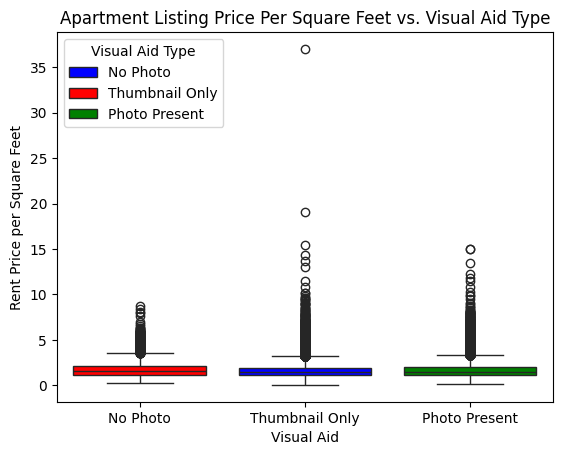

In [ ]:
sns.boxplot(apartments_4,
            x="has_photo",
            y="price_per_sqft",
            hue= "has_photo",
            palette= ["blue", "red", "green"],
            order= ["No", "Thumbnail", "Yes"],
            saturation= 1)
plt.xlabel("Visual Aid")
plt.ylabel("Rent Price per Square Feet")
plt.xticks(ticks= range(len(viz_labels)), labels=viz_labels)
plt.title("Apartment Listing Price Per Square Feet vs. Visual Aid Type")
plt.legend(title="Visual Aid Type", loc= 'upper left', labels= viz_labels)
plt.show()

In [ ]:
apartments_5 = apartments_4[apartments_4['price_per_sqft'] < 5]
#Another visualization was created using the isolated price per square foot values below 5
#This will help observe the experience of an average renter.

In [ ]:
apartments_5.head(3)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,square_feet,address,cityname,state,latitude,longitude,source,time,plot_price,price_per_sqft
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,542.0,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09,2195.0,4.049815
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,1500.0,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09,1250.0,0.833333
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,1650.0,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09,1395.0,0.845455


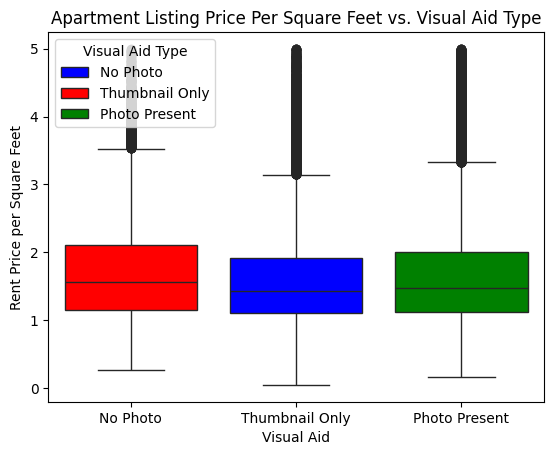

In [ ]:
sns.boxplot(apartments_5,
            x="has_photo",
            y="price_per_sqft",
            hue= "has_photo",
            palette= ["blue", "red", "green"],
            order= ["No", "Thumbnail", "Yes"],
            saturation= 1)
plt.xlabel("Visual Aid")
plt.ylabel("Rent Price per Square Feet")
plt.xticks(ticks= range(len(viz_labels)), labels=viz_labels)
plt.title("Apartment Listing Price Per Square Feet vs. Visual Aid Type")
plt.legend(title="Visual Aid Type", loc= 'upper left', labels= viz_labels)
plt.show()

**Analysis**

Based on this visualization, there is not a significant difference between the Rent prices for those who have no visual aid, a thumbnail, or a visual aid.

While the median rent remains consistent across all groups, listings without visual aids show a slightly wider interquartile range, suggesting a more varied pricing strategy in that category compared to listings with thumbnails or photos.

While all three categories exhibit high-end outliers starting around 3,000 dollars, the full distribution reveals extreme "ultra-luxury" outliers that reach as high as 52,000 dollars. The presence of these extreme values- particularly in the "Thumbnail Only" and "Photo Present" categories- suggests that while luxury pricing exists across all visual aid types, the most expensive premium listings are almost exclusively paired with some form of visual representation.

The extreme positive skew across all three groups indicates that the apartment market is heavily concentrated at the lower end of the price spectrum. Since the median is so close to the bottom whisker, a "typical" apartment price is suggested to be much closer to the market minimum than the market maximum, regardless of visual aid type.

#Conclusions

**Question 1 Conclusion**



**Question 2 Conclusion**

Overall, the three graphs successfully identified clear geographic pricing patterns within the dataset and provided meaningful insights into regional market concentration and pricing affordability. The results showed that property values are heavily concentrated in coastal markets, particularly in California and the Northeast, where both state-level and city-level pricing signifcantly exceeded national averages.

Together, the visualizations and supporting analysis effectively answered the research question regarding how geographic location influences apartment pricing and market concentration.

While this analysis was effective for identifying broad trends and geographic outliers, a better approach could provide deeper insights. For example, applying a regression model to data concerning location could give us a more sound conclusion to how price is impacted by location.

Additionally, the dataset lacked several variables that would give a better analysis. Some missing factors include city crime rates, school district quality, and employment statistics; all of these would impact the price of an apartment.

**Question 3 Conclusion**

Note: Unfortunately, while my code for RQ3 was able to run on its own in a separate colab folder, for whatever reason when I integrated it into the main project file, the error "ValueError: Columns must be same length as key" would appear; not knowing how to fix it and having spent hours trying to do so, I had to do the best I could, despite the OLS Regression results not matching the separate file's results.

The regression reported a statistically significant negative resulting coefficient of -43760 on bedroom count; essentially, a decrease of $43760 in listed rental price occurs with every extra bedroom an apartment unit has. The model is statistically significant as whole according to the F-statistic, which has a value of 4.334 and a p-value of 0.037. The intercept of 139700 conveys an apartment's starting price when it has 0 bedrooms.

This information doesn't seem logistically sound (b/c rental prices typically increase with each added bedroom) although the coeffcient is statistically significant. The bedroom count only seems to account for 0.1% of the variation in prices displayed, as per the R-squared value (0.001); therefore, bedroom count is a very weak predictor of price and other factors not mentioned in the model are more relevant predictors of price variation.

The OLS regression was not effective b/c of extreme outliers present in the dataset, in addition to many variables that influence rental prices, such as location, amenities, etc. So while the regression did identify a statistically meaningful relationship between listed prices and bedroom counts, as indicated by the low R-squared score, a less biased, more accurate coefficient could have resulted if more variables had been factored in as a multiple regression.  

Several factors were missing that could have greatly impacted the dataset, i.e., proximity to public transport, availability of an elevator, and building age. The amenities column was dropped early on because it was loaded with inconsistent entries and commas and lacked the clean, binary structure needed. This column would have been useful if included, but it lacked the proper formatting.

I have attached a link to my separate Colab file, which displays the hopefully more accurate OLS regression results: https://colab.research.google.com/drive/1LVPO40rlC6BL7JLYj4IHW484_adNeb3I?usp=sharing

**Question 4 Conclusion**

While median rent remains consistent across all visual aid types, the inclusion of photos or thumbnails serves as a mandatory standard for the luxury market (listings ≥ $20,000), where extreme outliers reach values as high as 35 dollars per square foot. In the general market, visual aids do not correlate with higher prices. However, normalizing the data reveals that "No Photo" listings actually carry a higher median price per square foot, likely representing smaller, high-demand urban units where location drives the premium.

The current analysis was effective in visualizing the extreme positive skew of the apartment market. By identifying that the "typical" apartment price sits much closer to the market minimum than the maximum, the visualization was able to isolate the luxury outliers without distorting the story of the average renter.

However, to achieve a more sophisticated level of accuracy, I suggest that future iterations move toward Price Stratification. Since the volume of budget-friendly listings "washes out" the differences of the luxury market, separating the data into Low, Middle, and High-tier brackets would allow for a more descriptive look at how visual marketing strategies differ across socio-economic groups.

While the Price per Square Foot calculation provided depth to the "value" of each unit, the dataset remains limited by a lack of temporal data. In order to fully understand the return on investment of visual aids, we would need to observe the listing age on the market. While our data shows that photos don't necessarily lead to a higher price, they may lead to a faster sale. Incorporating the time it takes for a listing to be claimed would determine if the real benefit of a photo is the speed of the transaction rather than the dollar amount of the rent. While the dataset includes a "time" column, this measures the time each posting first appeared on the market, rather than its selling time.